In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("letter-recognition.data",header=None)
df.head()               

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [3]:
df.columns = ['letter','x1','x2','x3','x4','x5','x6','x7','x8',
              'x9','x10','x11','x12','x13','x14','x15','x16']
df.head()

,letter,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [4]:
X=df.drop('letter',axis=1)
y=df['letter']
X.shape
y.shape

(20000,)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  LabelEncoder,StandardScaler

encoder=LabelEncoder()
y=encoder.fit_transform(y)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model=Sequential()
model.add(Dense(64,activation='relu',input_shape=(16,)))
model.add(Dense(32,activation='relu'))
model.add(Dense(26,activation='softmax'))      

model.compile(
    optimizer='adam',                           # optimizer
    loss='sparse_categorical_crossentropy',     # for integer labels
    metrics=['accuracy']                        # evaluation metric
)

# Display a summary of the model architecture
model.summary()

C:\Users\praja\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 26)                  │             858 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,026 (15.73 KB)

 Trainable params: 4,026 (15.73 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history=model.fit(X_train,y_train,epochs=5,batch_size=32,validation_split=0.1)

Epoch 1/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.4735 - loss: 1.9170 - val_accuracy: 0.6756 - val_loss: 1.1100
Epoch 2/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7272 - loss: 0.9393 - val_accuracy: 0.7600 - val_loss: 0.8241
Epoch 3/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7872 - loss: 0.7279 - val_accuracy: 0.8025 - val_loss: 0.6678
Epoch 4/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8259 - loss: 0.6073 - val_accuracy: 0.8294 - val_loss: 0.5805
Epoch 5/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8490 - loss: 0.5283 - val_accuracy: 0.8500 - val_loss: 0.5190


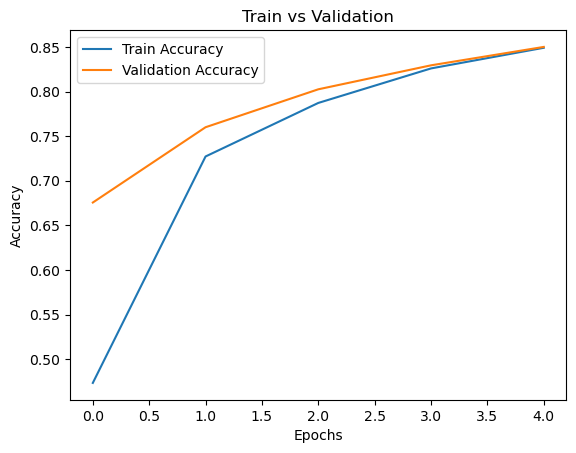

In [15]:
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Train vs Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [19]:
y_pred=np.argmax(model.predict(X_test),axis=1)
from sklearn.metrics import confusion_matrix
import seaborn as sns

sns.heatmap(cm,annot=True,cmap='Blue'
cm=confusion_matrix(y_test,y_pred)
print(cm)

                 

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
[[139   0   0   0   0   0   0   0   0   0   2   0   1   0   0   0   0   2
    1   0   2   0   0   1   1   0]
 [  0 129   0   3   0   0   0   2   0   0   1   0   0   1   1   4   0  10
    1   0   0   0   0   0   1   0]
 [  0   0 106   0   5   0   4   2   0   0   7   0   0   0   6   0   1   1
    1   0   3   1   0   0   0   0]
 [  2   3   0 126   0   2   0   3   0   5   1   0   1   4   0   1   0   5
    0   1   0   0   0   0   0   2]
 [  0   0   0   0 127   0   1   0   0   0   3   0   0   0   0   0   3   1
    1   1   0   0   0   1   0   3]
 [  0   1   0   0   1 120   2   2   2   2   0   0   0   0   0   1   0   1
    5   2   0   0   0   0   0   1]
 [  0   0   4   0   0   0 129   1   0   0   5   1   0   0   1   2   5   4
    2   0   0   1   3   2   0   0]
 [  0   2   0   2   0   2   0 100   0   1   4   0   1   5   3   1   2  15
    3   0   2   0   0   1   0   0]
 [  0   0   0   2   1   1   0   0 122   3   0   2   0   0   0   1   3   0
    3   0   0